# Volatility Drag: An Educational Walkthrough

When you compound random returns over time, the rate of growth a *typical* realised path achieves is *less* than the average return across the ensemble of all possible paths. The gap is **volatility drag**, and for Geometric Brownian Motion (GBM) it equals exactly $\tfrac{1}{2}\sigma^2$.

This notebook builds the concept from the ground up:

1. **Why drag exists at all** — Jensen's inequality and the Taylor expansion of $\log(1+r)$
2. **The closed-form GBM result** — Itô's lemma and the appearance of $\mu - \tfrac{1}{2}\sigma^2$
3. **How big drag is in practice** — the dimensionless ratio $\sigma^2 / (2\mu)$
4. **The regime map** — when drag is invisible, material, critical, or self-defeating
5. **How leverage interacts with drag** — quadratic scaling and the Kelly ceiling
6. **A worked example** — levering a high-Sharpe systematic strategy 5x
7. **Caveats** — when GBM is the wrong model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from voldrag.analytics import (
    volatility_drag,
    geometric_mean_return,
    ensemble_mean,
    median_terminal,
    prob_path_below_mean,
)
from voldrag.gbm import simulate_gbm
from voldrag.experiments import coin_flip_game, sigma_sweep
from voldrag.plots import (
    plot_path_fan,
    plot_terminal_distribution,
    plot_sigma_sweep,
    plot_regime_map,
)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Why drag exists — the asymmetry of multiplication

A 50% loss requires a 100% gain to recover. That single fact contains the whole story.

If your wealth multiplies by $1+r$ and then by $1-r$, the result is $1 - r^2$ — not $1$. The arithmetic mean return is zero, but the typical realised result is a loss equal to $r^2$.

Generalising: $\log(1+r) \approx r - r^2/2$. The first term is what gets averaged into your drift; the **second term is volatility drag**. Nothing more mysterious than the second-order term of a Taylor series.

In [2]:
def two_period(r):
    return (1 + r) * (1 - r)

rows = []
for r in [0.05, 0.10, 0.20, 0.50]:
    rows.append({
        "r": r,
        "wealth after +r, -r": two_period(r),
        "loss": 1 - two_period(r),
        "r^2 (predicted)": r * r,
    })
pd.DataFrame(rows)

,r,"wealth after +r, -r",loss,r^2 (predicted)
0,0.05,0.9975,0.0025,0.0025
1,0.10,0.9900,0.0100,0.0100
2,0.20,0.9600,0.0400,0.0400
3,0.50,0.7500,0.2500,0.2500


The loss is *exactly* $r^2$. The bigger the swing, the bigger the gap between arithmetic break-even and your actual outcome. Variance is automatically a quadratic cost on compounding.

## 2. The GBM result

For Geometric Brownian Motion,

$$\frac{dS_t}{S_t} = \mu\, dt + \sigma\, dW_t,$$

Itô's lemma gives an *exact* result for $\log S_t$:

$$\log S_t = \left(\mu - \tfrac{1}{2}\sigma^2\right) t + \sigma W_t.$$

So $\log S_t$ is normal with mean $\left(\mu - \tfrac{1}{2}\sigma^2\right) t$, and $S_t$ is log-normal. Two different "expected returns" live in the same model:

| Quantity | Formula | Interpretation |
|---|---|---|
| Arithmetic / ensemble mean | $\mathbb{E}[S_t] = e^{\mu t}$ | Average across all parallel paths |
| Geometric / time-average | $\text{median}(S_t) = e^{(\mu - \sigma^2/2)\,t}$ | Growth a single path realises with probability 1 |
| **Volatility drag** | $\tfrac{1}{2}\sigma^2$ | The gap between the two |

Let's see this in a simulation. We'll use $\mu = 10\%$, $\sigma = 30\%$, over 30 years — equity-like numbers where drag is visible.

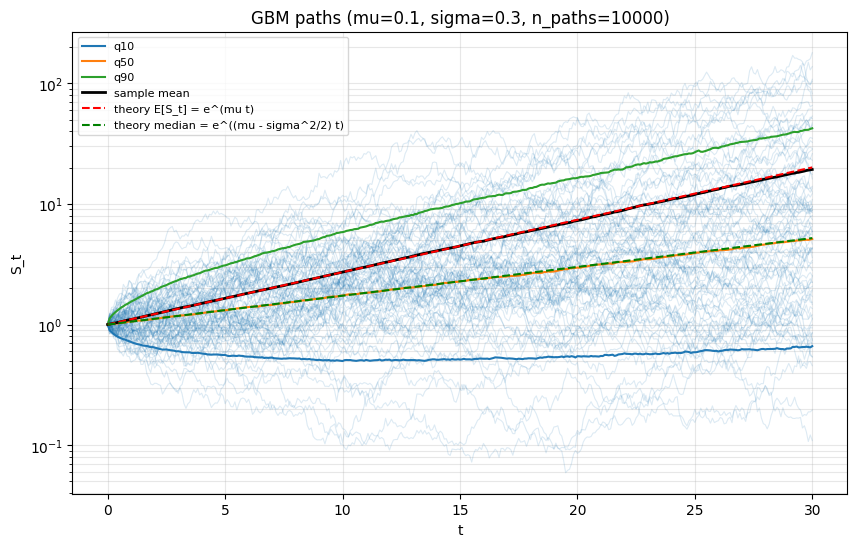

In [3]:
paths = simulate_gbm(mu=0.10, sigma=0.30, t=30.0, n_steps=30 * 12, n_paths=10_000, seed=0)
fig, ax = plt.subplots(figsize=(10, 6))
plot_path_fan(paths, n_to_plot=80, ax=ax)
plt.show()

The black line is the *sample mean*; the red dashed line is $e^{\mu t}$ — they coincide.
The green dashed line is $e^{(\mu - \sigma^2/2)\,t}$ — the typical path. Notice it's well below the mean, and the gap grows with $t$.

The 10th, 50th, and 90th quantile curves show the spread of outcomes. **Most paths track the median, not the mean** — the mean is propped up by a thin upper tail.

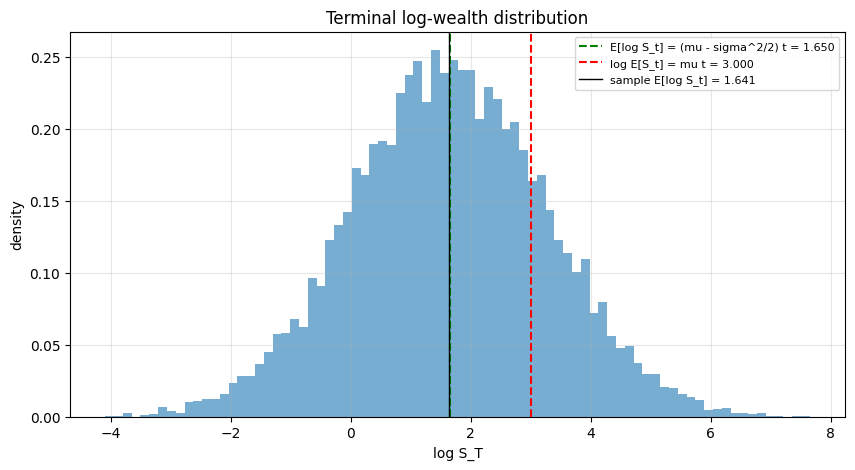

Theoretical E[S_30]    =   20.086
Sample mean S_30       =   19.321
Theoretical median     =    5.207
Sample median S_30     =    5.118
P(S_30 < E[S_30])      =    0.797


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_terminal_distribution(paths, ax=ax)
plt.show()

terminal = paths.terminal
print(f"Theoretical E[S_30]    = {ensemble_mean(0.10, 30.0):8.3f}")
print(f"Sample mean S_30       = {terminal.mean():8.3f}")
print(f"Theoretical median     = {median_terminal(0.10, 0.30, 30.0):8.3f}")
print(f"Sample median S_30     = {np.median(terminal):8.3f}")
print(f"P(S_30 < E[S_30])      = {(terminal < ensemble_mean(0.10, 30.0)).mean():8.3f}")

**~75% of paths finish below the ensemble mean.** Yet the mean is correct: the upper 25% (and especially the upper 1%) are doing well enough to pull the average up. If you only get one path, that fact is cold comfort.

## 3. When does drag matter? The ratio $\sigma^2 / (2\mu)$

Drag in absolute terms isn't directly meaningful — 1% drag is huge if your drift is 2% and trivial if your drift is 20%. The right quantity is drag as a *fraction* of drift:

$$\frac{\tfrac{1}{2}\sigma^2}{\mu} = \frac{\sigma^2}{2\mu}.$$

This dimensionless ratio splits strategies into regimes:

| $\sigma^2 / (2\mu)$ | Regime | Meaning |
|---|---|---|
| < 5% | Invisible | Plan in arithmetic terms |
| 10–30% | Material | You forfeit 10–30% of your return |
| 50–80% | Critical | Median is a small fraction of mean |
| ≈ 100% | Break-even | Typical wealth flat forever; mean still climbs |
| > 100% | Self-defeating | Typical wealth $\to 0$ even though $\mathbb{E}[S_t] \to \infty$ |

The break-even volatility for a given drift is $\sigma_\text{crit} = \sqrt{2\mu}$. For 10% drift that's 45% vol; for 4% drift only 28%.

In [5]:
assets = pd.DataFrame(
    [
        ("T-bills",         0.04, 0.01),
        ("IG bonds",        0.05, 0.06),
        ("Equity index",    0.10, 0.18),
        ("Large-cap stock", 0.12, 0.35),
        ("3x leveraged ETF",0.30, 0.60),
        ("BTC",             0.30, 0.70),
        ("Small-cap spec",  0.15, 0.80),
    ],
    columns=["asset", "mu", "sigma"],
)
assets["drag (1/2 sigma^2)"] = 0.5 * assets["sigma"] ** 2
assets["geometric (mu - drag)"] = assets["mu"] - assets["drag (1/2 sigma^2)"]
assets["ratio sigma^2/(2 mu)"] = assets["drag (1/2 sigma^2)"] / assets["mu"]
assets.set_index("asset")

,mu,sigma,drag (1/2 sigma^2),geometric (mu - drag),ratio sigma^2/(2 mu)
asset,,,,,
T-bills,0.04,0.01,0.00005,0.03995,0.001250
IG bonds,0.05,0.06,0.00180,0.04820,0.036000
Equity index,0.10,0.18,0.01620,0.08380,0.162000
Large-cap stock,0.12,0.35,0.06125,0.05875,0.510417
3x leveraged ETF,0.30,0.60,0.18000,0.12000,0.600000
BTC,0.30,0.70,0.24500,0.05500,0.816667
Small-cap spec,0.15,0.80,0.32000,-0.17000,2.133333


Look at the **3x leveraged ETF** row. It's sold on the headline "3x the index return" but the typical holder gets roughly the *geometric* return, which after 18% drag is often worse than just holding the unlevered index. This isn't a flaw in the product — it's $\tfrac{1}{2}\sigma^2$ doing exactly what it says on the tin.

## 4. The +60% / −50% coin flip

Time for a stark illustration. Consider a game where each round your wealth is multiplied by $1.6$ or $0.5$, with equal probability.

- Arithmetic expectation per round: $0.5 \times 1.6 + 0.5 \times 0.5 = 1.05$. A positive **5%** edge.
- Geometric expectation: $\mathbb{E}[\log M] = 0.5 \log 1.6 + 0.5 \log 0.5 \approx -0.112$. **Negative.**

The arithmetic edge says "play forever". The geometric reality says "you'll be wiped out". Which wins?

In [6]:
game = coin_flip_game(n_rounds=100, n_paths=50_000, seed=0)
print(game.report())

Multiplicative coin game: up x1.6, down x0.5, p_up=0.5
  rounds                 = 100
  paths                  = 50000
  E[multiplier]          = 1.050000 (> 1 means positive arithmetic edge)
  E[log multiplier]      = -0.111572 (< 0 means negative geometric edge)

  sample mean wealth     = 12.0107
  sample median wealth   = 0.0000
  fraction P(wealth > 1) = 0.0292
  (ensemble is positive, typical player is ruined)


Mean wealth climbs (the few players who get a long winning streak more than compensate for the rest). Median wealth is approximately zero — the typical player is wiped out. This is **the same effect** as in GBM, only made visceral by the discrete asymmetry: each loss takes a 60% gain to recover from, each gain only requires a 38% loss to undo. The arithmetic edge doesn't survive compounding.

## 5. Sigma sweep at fixed drift

The cleanest visualisation of drag: hold $\mu$ fixed and crank $\sigma$ up. The ensemble mean stays at $e^{\mu T}$. The median collapses.

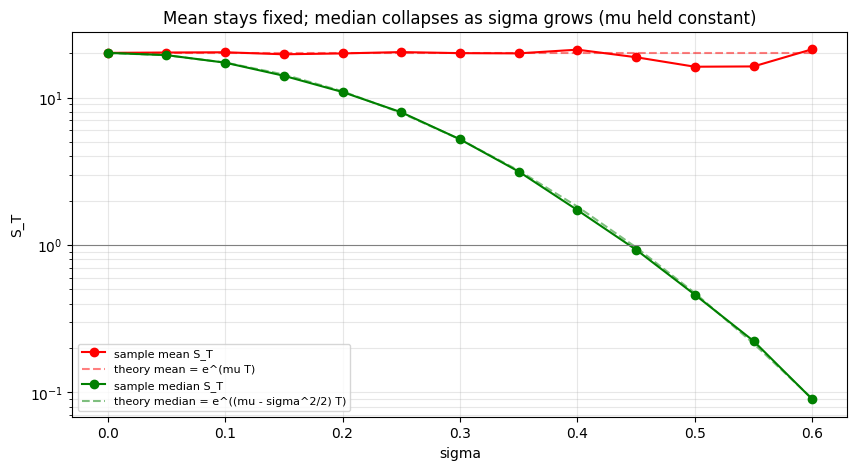

In [7]:
sweep = sigma_sweep(mu=0.10, t=30.0, n_paths=8_000, seed=0)
fig, ax = plt.subplots(figsize=(10, 5))
plot_sigma_sweep(sweep, ax=ax)
plt.show()

At 60% vol with 10% drift, the *expected* terminal wealth is still $e^{0.10 \times 30} \approx 20$. The *typical* terminal wealth is below 1 — i.e. the typical player has lost money over 30 years even though the strategy "expects" to 20x.

## 6. The regime map

Putting everything onto one chart: a heatmap of $\sigma^2 / (2\mu)$ over the $(\mu, \sigma)$ plane, with reference assets and the worked levered-strategy example marked. The dashed curve is the break-even line $\sigma = \sqrt{2\mu}$. To the right of it, typical wealth declines despite positive arithmetic expectation.

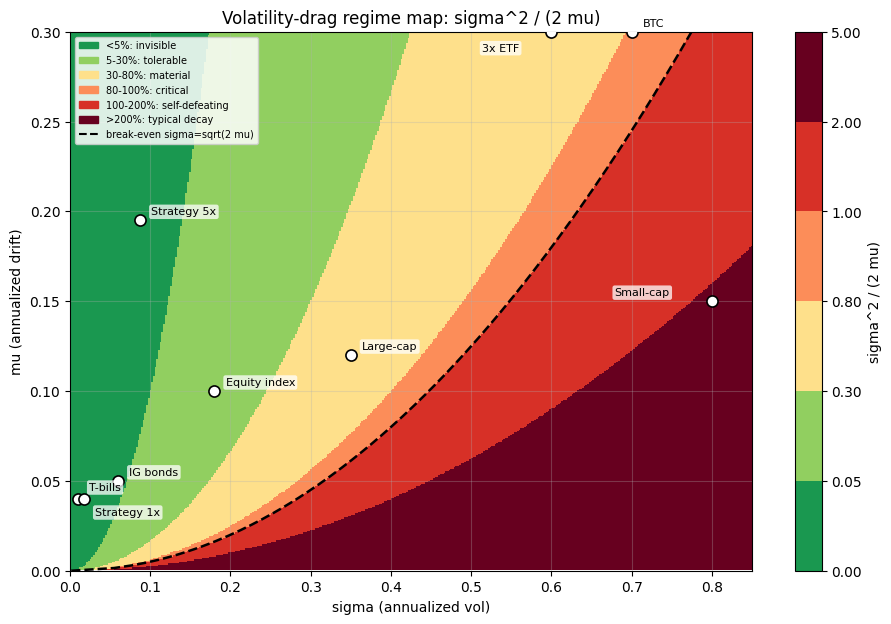

In [8]:
from voldrag.cli import REGIME_MARKERS

fig, ax = plt.subplots(figsize=(11, 7))
plot_regime_map(markers=REGIME_MARKERS, ax=ax)
plt.show()

## 7. How leverage interacts with drag

Apply leverage $L$ to a base strategy with parameters $(\mu, \sigma)$:

- gross drift scales linearly: $L\mu$
- volatility scales linearly: $L\sigma$
- **drag scales *quadratically*: $L^2 \cdot \tfrac{1}{2}\sigma^2$**

Including a leverage-financing cost $c(L)$, the geometric drift is

$$g(L) = L\mu - c(L) - L^2 \cdot \tfrac{1}{2}\sigma^2.$$

Differentiating in $L$ and ignoring the $L$-dependence of $c$ gives the growth-optimal **Kelly leverage**:

$$L^* = \frac{\mu}{\sigma^2}.$$

Past $L^*$, every additional turn of leverage *reduces* your typical compounded return. The drag has overtaken the drift. The key qualitative fact: drift is linear in $L$, drag is quadratic, so however tiny drag looks at $L=1$, there is always a leverage past which it dominates.

## 8. Worked example — levering a high-Sharpe systematic strategy

Suppose you have a systematic strategy with the following realised 10-year stats:

- $\mu = 4\%$ annualised
- $\sigma = 1.75\%$ annualised
- Sharpe-like ratio $\mu/\sigma \approx 2.29$ (very high)

You're considering levering it 5x at a 50bps annual financing cost. **What role does volatility drag play?**

In [9]:
mu_base = 0.04
sigma_base = 0.0175
L = 5
leverage_cost = 0.005

mu_gross_lev = L * mu_base
sigma_lev = L * sigma_base
mu_net_lev = mu_gross_lev - leverage_cost
drag_lev = 0.5 * sigma_lev ** 2
geometric_lev = mu_net_lev - drag_lev

print("Unlevered baseline")
print(f"  mu                     = {mu_base:7.4%}")
print(f"  sigma                  = {sigma_base:7.4%}")
print(f"  drag = 1/2 sigma^2     = {0.5 * sigma_base ** 2:7.4%}")
print(f"  ratio sigma^2/(2 mu)   = {(sigma_base ** 2) / (2 * mu_base):7.4%}   (invisible)")
print()
print(f"Levered {L}x with {leverage_cost:.2%} financing")
print(f"  Gross arithmetic       = L*mu                  = {mu_gross_lev:7.4%}")
print(f"  - Leverage cost        =                       = {leverage_cost:7.4%}")
print(f"  = Net arithmetic       =                       = {mu_net_lev:7.4%}")
print(f"  - Vol drag = L^2*sigma^2/2                     = {drag_lev:7.4%}")
print(f"  = Geometric drift                              = {geometric_lev:7.4%}")
print()
print("How big is drag in the levered strategy?")
print(f"  Drag as fraction of net drift = {drag_lev / mu_net_lev:7.2%}")
print(f"  (For comparison, leverage cost is              = {leverage_cost / mu_net_lev:7.2%} of net drift)")
print()
print("Where are we relative to the Kelly cliff?")
kelly_L = mu_base / sigma_base ** 2
breakeven_L = 2 * mu_base / sigma_base ** 2
print(f"  Kelly leverage L* = mu/sigma^2                 = {kelly_L:7.1f}x")
print(f"  Breakeven leverage (drag = gross drift)        = {breakeven_L:7.1f}x")
print(f"  You are at                                     = {L:7.1f}x")
print(f"  i.e. {L / kelly_L:.2%} of Kelly.")

Unlevered baseline
  mu                     = 4.0000%
  sigma                  = 1.7500%
  drag = 1/2 sigma^2     = 0.0153%
  ratio sigma^2/(2 mu)   = 0.3828%   (invisible)

Levered 5x with 0.50% financing
  Gross arithmetic       = L*mu                  = 20.0000%
  - Leverage cost        =                       = 0.5000%
  = Net arithmetic       =                       = 19.5000%
  - Vol drag = L^2*sigma^2/2                     = 0.3828%
  = Geometric drift                              = 19.1172%

How big is drag in the levered strategy?
  Drag as fraction of net drift =   1.96%
  (For comparison, leverage cost is              =   2.56% of net drift)

Where are we relative to the Kelly cliff?
  Kelly leverage L* = mu/sigma^2                 =   130.6x
  Breakeven leverage (drag = gross drift)        =   261.2x
  You are at                                     =     5.0x
  i.e. 3.83% of Kelly.


**Takeaway**: at 5x leverage, drag is about 2% of net return — smaller than the 50bps financing cost. The strategy's Sharpe is so high (2.29) that 5x is only ~4% of Kelly. Drag is a rounding error here; the bigger risks are parameter uncertainty, regime change in $\sigma$, and fat-tail / margin-call dynamics that GBM doesn't capture.

Let's plot the Kelly curve to see this visually.

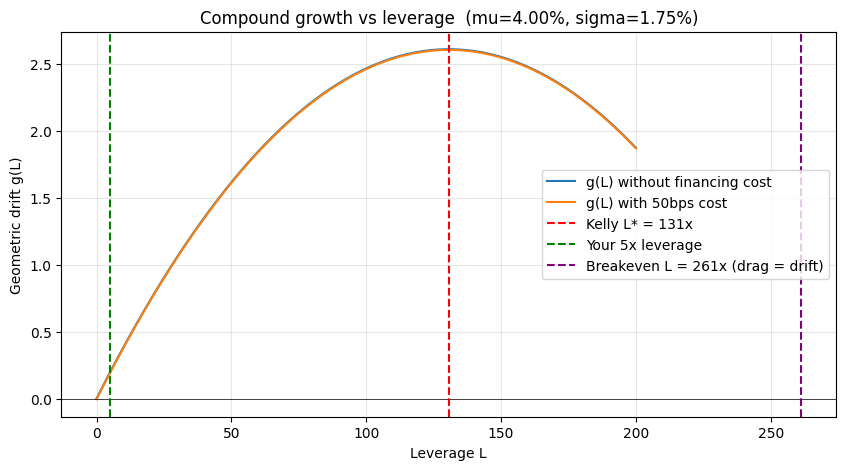

In [10]:
L_range = np.linspace(0, 200, 400)
g_no_cost = L_range * mu_base - 0.5 * (L_range * sigma_base) ** 2
g_with_cost = g_no_cost - leverage_cost

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(L_range, g_no_cost, label="g(L) without financing cost")
ax.plot(L_range, g_with_cost, label="g(L) with 50bps cost")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(kelly_L, color="red", linestyle="--", label=f"Kelly L* = {kelly_L:.0f}x")
ax.axvline(L, color="green", linestyle="--", label=f"Your {L}x leverage")
ax.axvline(breakeven_L, color="purple", linestyle="--",
           label=f"Breakeven L = {breakeven_L:.0f}x (drag = drift)")
ax.set_xlabel("Leverage L")
ax.set_ylabel("Geometric drift g(L)")
ax.set_title(
    f"Compound growth vs leverage  (mu={mu_base:.2%}, sigma={sigma_base:.2%})"
)
ax.legend()
plt.show()

The parabola peaks at Kelly. At 5x leverage you are deep on the rising left side of the curve — massive headroom before drag matters. The strategy is so efficient (Sharpe 2.29) that drag isn't the binding constraint; tail-risk tolerance and financing realism are.

Conversely, look at where 3x leveraged equity ETFs sit on the regime map (gross 30%, 60% vol). Their `sigma^2/(2 mu)` is ~60%, putting them *on the wrong side of Kelly's peak* — leverage is actively destroying their typical compounding even before management fees.

## 9. When GBM is the wrong model

The drag analysis assumes:

1. **Log-normal returns** — no jumps, no fat tails.
2. **Constant $\mu$ and $\sigma$** — no regime changes.
3. **Continuous trading** — no margin calls, no liquidity constraints.

In practice:

- **Regime changes**: if $\sigma$ doubles in a stress event, levered drag *quadruples*. A "tolerable" 5x position can move into the critical band overnight.
- **Fat tails**: a single −10% day at 5x leverage is a −50% drawdown — probably a margin call. $\tfrac{1}{2}\sigma^2$ tells you nothing about forced liquidation at the bottom.
- **Parameter uncertainty**: realised 10-year $\mu$ is only an estimate. If true $\mu$ is half what you measured, everything in the worked example shifts dramatically.

**Drag is necessary but not sufficient** for evaluating leverage. It's the smooth, predictable cost of variance. Tail risk and parameter uncertainty live on top of it.

## Summary

| Concept | Formula |
|---|---|
| Volatility drag | $\tfrac{1}{2}\sigma^2$ |
| Geometric (typical) growth rate | $\mu - \tfrac{1}{2}\sigma^2$ |
| Ensemble mean wealth | $\mathbb{E}[S_t] = e^{\mu t}$ |
| Typical (median) wealth | $e^{(\mu - \sigma^2/2)\,t}$ |
| Drag-to-drift ratio | $\sigma^2 / (2\mu)$ |
| Break-even volatility | $\sigma_\text{crit} = \sqrt{2\mu}$ |
| Kelly leverage | $L^* = \mu / \sigma^2$ |
| Drag scaling with leverage | quadratic, $L^2\sigma^2/2$ |

**The one frame to remember**: arithmetic returns describe a parallel-universe ensemble. Geometric returns describe your single life. If you only get one path, drag isn't a correction term — it's the actual number to plan around.